# 04 - Segmentation et mesures

## Objectif
Isoler correctement la pièce principale, puis détecter et mesurer les régions suspectes à l’intérieur d’une zone utile de la pièce.

## Travail réalisé
- préparation des images
- segmentation de la pièce principale
- suppression du fond
- construction d'une ROI annulaire
- détection des anomalies locales
- extraction de mesures simples
- comparaison OK vs Defective

## Idée importante
On ne cherche plus simplement des contours globaux.
On veut maintenant :
1. récupérer la vraie pièce
2. ignorer les structures normales
3. détecter des anomalies plus pertinentes pour la décision finale

In [145]:
# ==========================================
# 1. Imports
# ==========================================

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from src.preprocessing import preprocess_image
from src.filtering import apply_median_filter

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [146]:
# ==========================================
# 2. Fonctions utilitaires
# ==========================================

DATASET_DIR = Path("../data/raw/casting_data")

train_ok_dir = DATASET_DIR / "train" / "ok_front"
train_def_dir = DATASET_DIR / "train" / "def_front"

def list_images(folder):
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for ext in extensions:
        files.extend(folder.glob(ext))
    return sorted(files)

def load_grayscale_image(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")
    return img

train_ok_images = list_images(train_ok_dir)
train_def_images = list_images(train_def_dir)

print(f"Train OK       : {len(train_ok_images)}")
print(f"Train Defective: {len(train_def_images)}")

Train OK       : 2875
Train Defective: 3758


In [147]:
# ==========================================
# 3. Choisir deux images exemple
# ==========================================

ok_path = random.choice(train_ok_images)
def_path = random.choice(train_def_images)

ok_img = load_grayscale_image(ok_path)
def_img = load_grayscale_image(def_path)

print("Image OK choisie       :", ok_path.name)
print("Image Defective choisie:", def_path.name)

Image OK choisie       : cast_ok_0_5268.jpeg
Image Defective choisie: cast_def_0_6285.jpeg


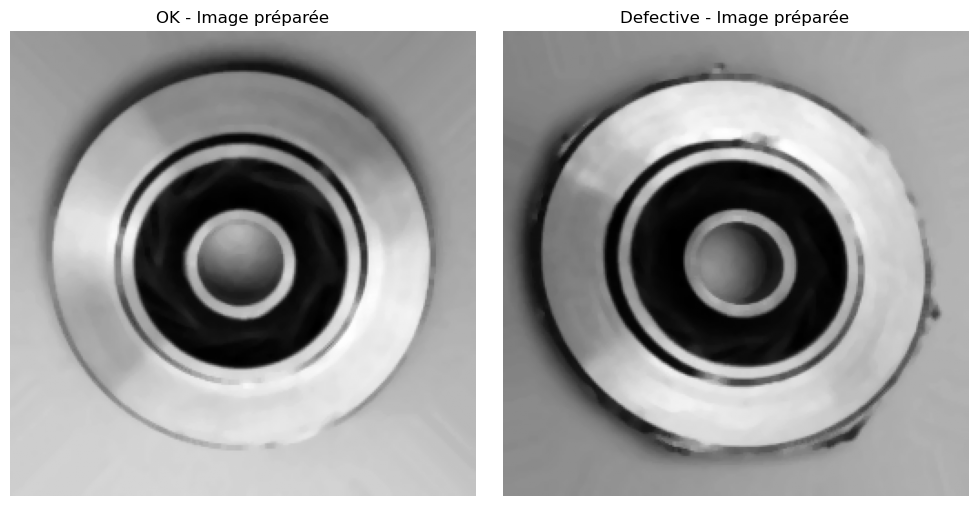

In [172]:
# ==========================================
# 4. Préparation des images
# ==========================================

def prepare_image(img, target_size=(256, 256)):
    img_pre = preprocess_image(img, target_size=target_size)
    img_filtered = apply_median_filter(img_pre, kernel_size=5)
    return img_filtered

ok_prepared = prepare_image(ok_img)
def_prepared = prepare_image(def_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ok_prepared, cmap="gray")
axes[0].set_title("OK - Image préparée")
axes[0].axis("off")

axes[1].imshow(def_prepared, cmap="gray")
axes[1].set_title("Defective - Image préparée")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [173]:
# ==========================================
# 5. Nettoyage morphologique
# ==========================================

def morphological_cleaning(binary_img, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    opened = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return cleaned

In [174]:
# ==========================================
# 6. Segmentation de la pièce par cercle
# ==========================================

def detect_piece_circle(img_prepared, dp=1.2, min_dist=80, param1=100, param2=30,
                        min_radius=70, max_radius=120):
    """
    Détecte le cercle principal de la pièce avec HoughCircles.
    """
    blurred = cv2.GaussianBlur(img_prepared, (9, 9), 2)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=dp,
        minDist=min_dist,
        param1=param1,
        param2=param2,
        minRadius=min_radius,
        maxRadius=max_radius
    )

    if circles is None:
        return None

    circles = np.round(circles[0]).astype(int)

    H, W = img_prepared.shape
    img_cx, img_cy = W / 2, H / 2

    best_circle = None
    best_score = -1

    for x, y, r in circles:
        dist = np.sqrt((x - img_cx) ** 2 + (y - img_cy) ** 2)

        # privilégier cercle grand et proche du centre
        score = r - 0.5 * dist

        if score > best_score:
            best_score = score
            best_circle = (x, y, r)

    return best_circle


def segment_main_object_circle(img_prepared):
    """
    Segmente la pièce comme un disque principal.
    """
    circle = detect_piece_circle(img_prepared)

    if circle is None:
        return {
            "mask": np.zeros_like(img_prepared),
            "center": None,
            "radius": 0,
            "selected_mode": "HOUGH_FAILED"
        }

    x, y, r = circle

    mask = np.zeros_like(img_prepared)
    cv2.circle(mask, (x, y), r, 255, thickness=-1)

    return {
        "mask": mask,
        "center": (x, y),
        "radius": r,
        "selected_mode": "HOUGH_CIRCLE"
    }

In [175]:
# ==========================================
# 7. Appliquer la segmentation circulaire
# ==========================================

ok_main = segment_main_object_circle(ok_prepared)
def_main = segment_main_object_circle(def_prepared)

print("OK  -> mode choisi :", ok_main["selected_mode"], "| center :", ok_main["center"], "| radius :", ok_main["radius"])
print("DEF -> mode choisi :", def_main["selected_mode"], "| center :", def_main["center"], "| radius :", def_main["radius"])

print("Ratio blanc masque OK  :", np.mean(ok_main["mask"] == 255))
print("Ratio blanc masque DEF :", np.mean(def_main["mask"] == 255))

OK  -> mode choisi : HOUGH_CIRCLE | center : (np.int64(127), np.int64(127)) | radius : 71
DEF -> mode choisi : HOUGH_CIRCLE | center : (np.int64(131), np.int64(118)) | radius : 110
Ratio blanc masque OK  : 0.2412872314453125
Ratio blanc masque DEF : 0.5795440673828125


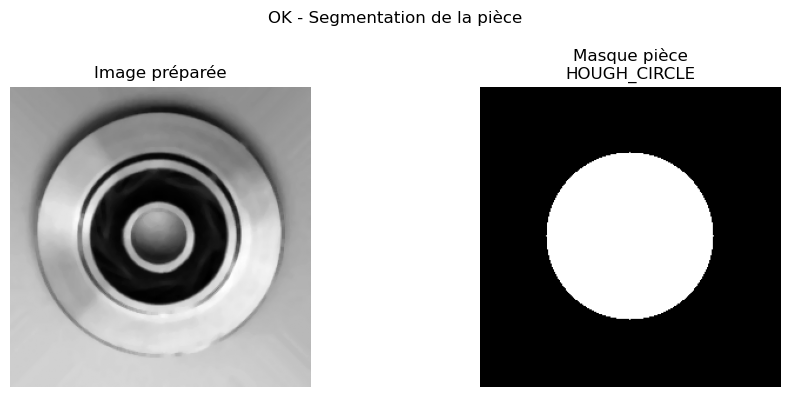

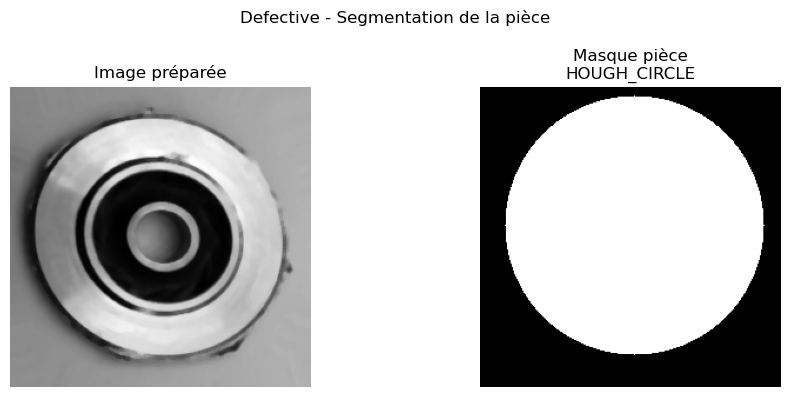

In [176]:
# ==========================================
# 8. Visualiser la segmentation de la pièce
# ==========================================

def show_circle_segmentation(prepared_img, result, title="Segmentation de la pièce"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(prepared_img, cmap="gray")
    axes[0].set_title("Image préparée")
    axes[0].axis("off")

    axes[1].imshow(result["mask"], cmap="gray")
    axes[1].set_title(f"Masque pièce\n{result['selected_mode']}")
    axes[1].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_circle_segmentation(ok_prepared, ok_main, title="OK - Segmentation de la pièce")
show_circle_segmentation(def_prepared, def_main, title="Defective - Segmentation de la pièce")

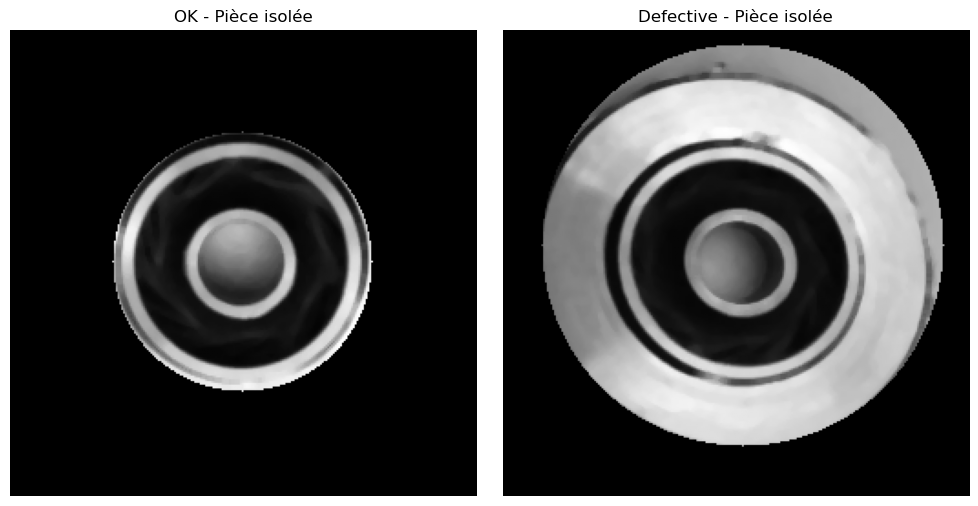

In [177]:
# ==========================================
# 9. Isoler uniquement la pièce
# ==========================================

def apply_mask(gray_img, mask):
    return cv2.bitwise_and(gray_img, gray_img, mask=mask)

ok_piece_only = apply_mask(ok_prepared, ok_main["mask"])
def_piece_only = apply_mask(def_prepared, def_main["mask"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ok_piece_only, cmap="gray")
axes[0].set_title("OK - Pièce isolée")
axes[0].axis("off")

axes[1].imshow(def_piece_only, cmap="gray")
axes[1].set_title("Defective - Pièce isolée")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [178]:
# ==========================================
# 10. Centre et rayon de la pièce
# ==========================================

ok_center, ok_radius = ok_main["center"], ok_main["radius"]
def_center, def_radius = def_main["center"], def_main["radius"]

print("OK  -> center:", ok_center, "| radius:", ok_radius)
print("DEF -> center:", def_center, "| radius:", def_radius)

OK  -> center: (np.int64(127), np.int64(127)) | radius: 71
DEF -> center: (np.int64(131), np.int64(118)) | radius: 110


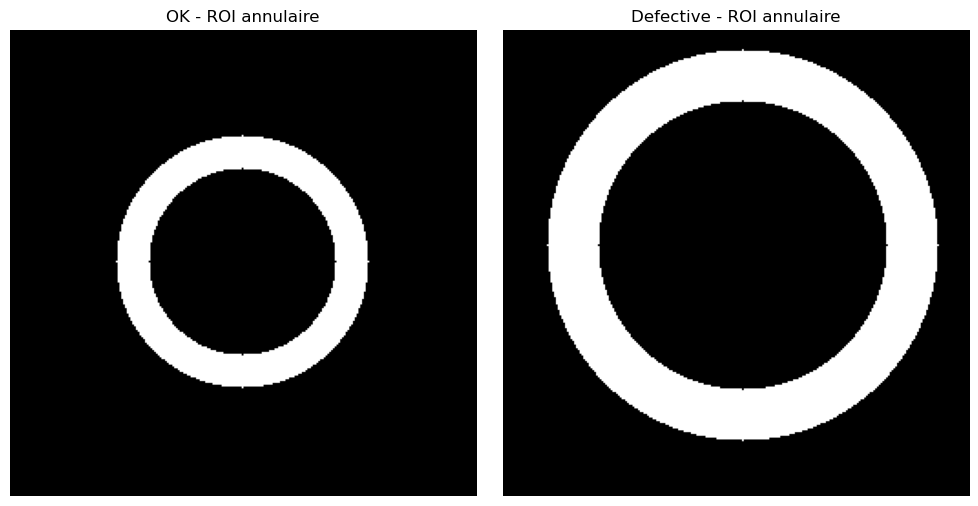

In [179]:
# ==========================================
# 11. ROI annulaire utile
# ==========================================

def create_annulus_mask(image_shape, center, r_inner, r_outer):
    mask = np.zeros(image_shape, dtype=np.uint8)
    cv2.circle(mask, center, int(r_outer), 255, thickness=-1)
    cv2.circle(mask, center, int(r_inner), 0, thickness=-1)
    return mask

ok_roi = create_annulus_mask(
    ok_prepared.shape,
    ok_center,
    r_inner=0.72 * ok_radius,
    r_outer=0.98 * ok_radius
)

def_roi = create_annulus_mask(
    def_prepared.shape,
    def_center,
    r_inner=0.72 * def_radius,
    r_outer=0.98 * def_radius
)

ok_roi = cv2.bitwise_and(ok_roi, ok_main["mask"])
def_roi = cv2.bitwise_and(def_roi, def_main["mask"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ok_roi, cmap="gray")
axes[0].set_title("OK - ROI annulaire")
axes[0].axis("off")

axes[1].imshow(def_roi, cmap="gray")
axes[1].set_title("Defective - ROI annulaire")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [180]:
# ==========================================
# 12. Fonctions contours
# ==========================================

def detect_contours(binary_img, retrieval_mode=cv2.RETR_EXTERNAL, approx_method=cv2.CHAIN_APPROX_SIMPLE):
    contours, hierarchy = cv2.findContours(binary_img.copy(), retrieval_mode, approx_method)
    return contours, hierarchy

def filter_contours_by_area(contours, min_area=20):
    return [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area]

def filter_contours_far_from_center(contours, piece_center, min_center_distance):
    filtered = []

    cx_piece, cy_piece = piece_center

    for cnt in contours:
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue

        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]

        dist = np.sqrt((cx - cx_piece) ** 2 + (cy - cy_piece) ** 2)

        if dist >= min_center_distance:
            filtered.append(cnt)

    return filtered

In [181]:
# ==========================================
# 13. Détection des anomalies locales
# ==========================================

def segment_suspicious_regions_v2(piece_img, roi_mask, piece_center, piece_radius, blur_size=31, min_area=20):
    background = cv2.GaussianBlur(piece_img, (blur_size, blur_size), 0)

    # différences locales sombres
    residual = cv2.subtract(background, piece_img)

    # limiter à la ROI
    residual_roi = cv2.bitwise_and(residual, residual, mask=roi_mask)

    # seuillage automatique
    _, binary = cv2.threshold(residual_roi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    cleaned = morphological_cleaning(binary, kernel_size=3)

    contours, _ = detect_contours(cleaned)
    filtered_contours = filter_contours_by_area(contours, min_area=min_area)

    # supprimer les contours trop proches du centre normal
    filtered_contours = filter_contours_far_from_center(
        filtered_contours,
        piece_center=piece_center,
        min_center_distance=0.22 * piece_radius
    )

    suspicious_mask = np.zeros_like(cleaned)
    if len(filtered_contours) > 0:
        cv2.drawContours(suspicious_mask, filtered_contours, -1, 255, thickness=cv2.FILLED)

    return {
        "background": background,
        "residual": residual,
        "binary": binary,
        "cleaned": cleaned,
        "filtered_contours": filtered_contours,
        "suspicious_mask": suspicious_mask
    }

In [182]:
# ==========================================
# 14. Application sur OK et Defective
# ==========================================

ok_suspicious = segment_suspicious_regions_v2(
    ok_piece_only,
    ok_roi,
    piece_center=ok_center,
    piece_radius=ok_radius,
    blur_size=31,
    min_area=20
)

def_suspicious = segment_suspicious_regions_v2(
    def_piece_only,
    def_roi,
    piece_center=def_center,
    piece_radius=def_radius,
    blur_size=31,
    min_area=20
)

print("OK  - régions suspectes :", len(ok_suspicious["filtered_contours"]))
print("DEF - régions suspectes :", len(def_suspicious["filtered_contours"]))

OK  - régions suspectes : 2
DEF - régions suspectes : 2


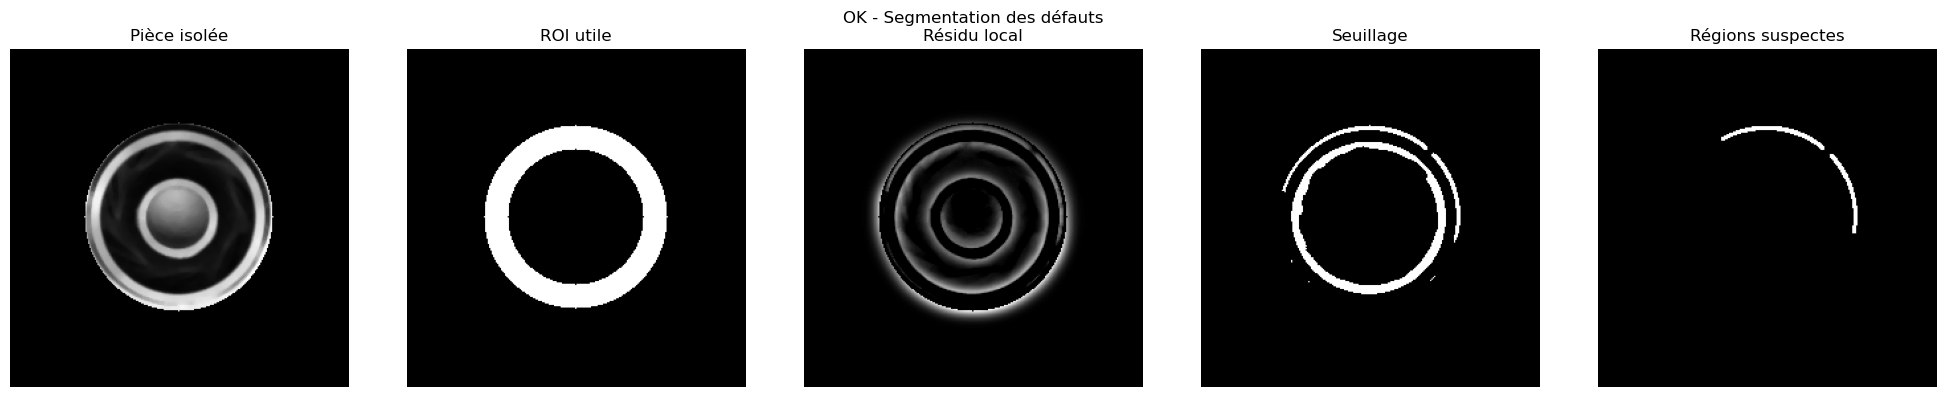

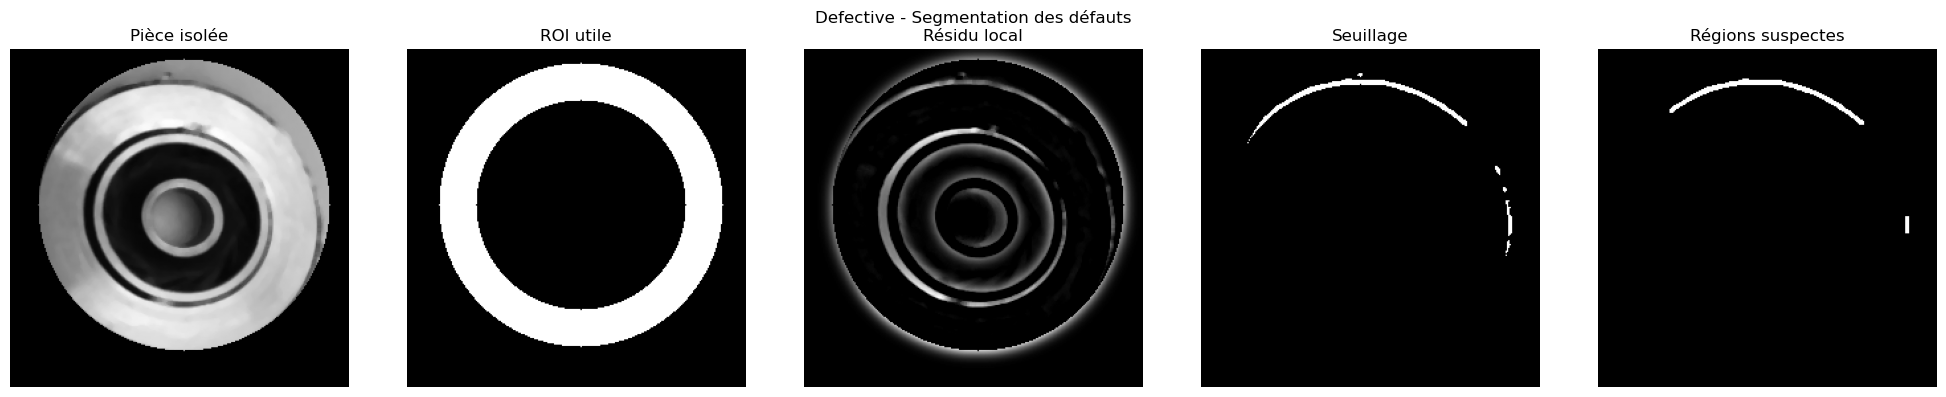

In [183]:
# ==========================================
# 15. Visualiser la segmentation des défauts
# ==========================================

def show_suspicious_segmentation(piece_img, roi_mask, result, title="Segmentation des zones suspectes"):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    axes[0].imshow(piece_img, cmap="gray")
    axes[0].set_title("Pièce isolée")
    axes[0].axis("off")

    axes[1].imshow(roi_mask, cmap="gray")
    axes[1].set_title("ROI utile")
    axes[1].axis("off")

    axes[2].imshow(result["residual"], cmap="gray")
    axes[2].set_title("Résidu local")
    axes[2].axis("off")

    axes[3].imshow(result["binary"], cmap="gray")
    axes[3].set_title("Seuillage")
    axes[3].axis("off")

    axes[4].imshow(result["suspicious_mask"], cmap="gray")
    axes[4].set_title("Régions suspectes")
    axes[4].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_suspicious_segmentation(ok_piece_only, ok_roi, ok_suspicious, title="OK - Segmentation des défauts")
show_suspicious_segmentation(def_piece_only, def_roi, def_suspicious, title="Defective - Segmentation des défauts")

In [184]:
# ==========================================
# 16. Résumé des contours
# ==========================================

def summarize_contours(contours):
    if len(contours) == 0:
        return {
            "num_contours": 0,
            "total_area": 0,
            "max_area": 0,
            "mean_area": 0,
            "total_perimeter": 0
        }

    areas = [cv2.contourArea(c) for c in contours]
    perimeters = [cv2.arcLength(c, True) for c in contours]

    return {
        "num_contours": len(contours),
        "total_area": float(np.sum(areas)),
        "max_area": float(np.max(areas)),
        "mean_area": float(np.mean(areas)),
        "total_perimeter": float(np.sum(perimeters))
    }

In [185]:
# ==========================================
# 17. Ratio de surface suspecte
# ==========================================

def suspicious_area_ratio(piece_mask, suspicious_mask):
    piece_area = np.sum(piece_mask == 255)
    suspicious_area = np.sum(suspicious_mask == 255)

    if piece_area == 0:
        return 0

    return suspicious_area / piece_area

In [186]:
# ==========================================
# 18. Comparer les mesures
# ==========================================

ok_summary = summarize_contours(ok_suspicious["filtered_contours"])
def_summary = summarize_contours(def_suspicious["filtered_contours"])

ok_ratio = suspicious_area_ratio(ok_main["mask"], ok_suspicious["suspicious_mask"])
def_ratio = suspicious_area_ratio(def_main["mask"], def_suspicious["suspicious_mask"])

print("Résumé OK")
for k, v in ok_summary.items():
    print(f" - {k}: {v:.2f}" if isinstance(v, float) else f" - {k}: {v}")
print(f" - suspicious_area_ratio: {ok_ratio:.6f}")

print("\nRésumé Defective")
for k, v in def_summary.items():
    print(f" - {k}: {v:.2f}" if isinstance(v, float) else f" - {k}: {v}")
print(f" - suspicious_area_ratio: {def_ratio:.6f}")

Résumé OK
 - num_contours: 2
 - total_area: 349.00
 - max_area: 198.00
 - mean_area: 174.50
 - total_perimeter: 314.79
 - suspicious_area_ratio: 0.031050

Résumé Defective
 - num_contours: 2
 - total_area: 484.00
 - max_area: 460.00
 - mean_area: 242.00
 - total_perimeter: 367.91
 - suspicious_area_ratio: 0.017061


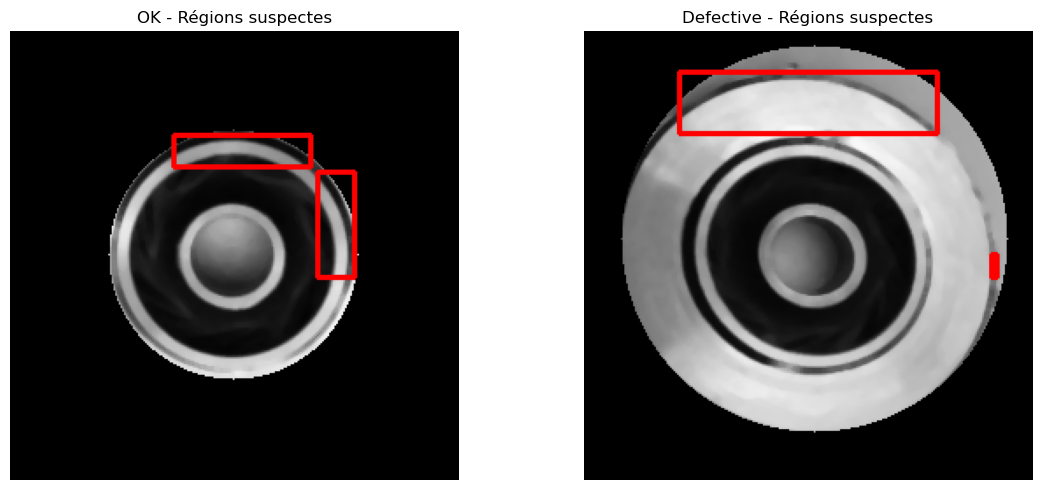

In [187]:
# ==========================================
# 19. Bounding boxes des régions suspectes
# ==========================================

def draw_bounding_boxes(gray_img, contours, thickness=2, min_area=10):
    img_rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), thickness)

    return img_rgb

ok_boxes = draw_bounding_boxes(ok_piece_only, ok_suspicious["filtered_contours"], thickness=2, min_area=10)
def_boxes = draw_bounding_boxes(def_piece_only, def_suspicious["filtered_contours"], thickness=2, min_area=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ok_boxes)
axes[0].set_title("OK - Régions suspectes")
axes[0].axis("off")

axes[1].imshow(def_boxes)
axes[1].set_title("Defective - Régions suspectes")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [188]:
# ==========================================
# 20. Pipeline complet
# ==========================================

def full_segmentation_pipeline_v2(img, min_area=20):
    prepared = prepare_image(img)

    main_obj = segment_main_object_circle(prepared)
    piece_only = apply_mask(prepared, main_obj["mask"])

    if main_obj["center"] is None:
        return None

    center, radius = main_obj["center"], main_obj["radius"]

    roi = create_annulus_mask(
        prepared.shape,
        center,
        r_inner=0.72 * radius,
        r_outer=0.98 * radius
    )
    roi = cv2.bitwise_and(roi, main_obj["mask"])

    suspicious = segment_suspicious_regions_v2(
        piece_only,
        roi,
        piece_center=center,
        piece_radius=radius,
        blur_size=31,
        min_area=min_area
    )

    ratio = suspicious_area_ratio(main_obj["mask"], suspicious["suspicious_mask"])

    return {
        "prepared": prepared,
        "main_obj": main_obj,
        "piece_only": piece_only,
        "roi": roi,
        "suspicious": suspicious,
        "ratio": ratio
    }

In [189]:
# ==========================================
# 21. Fonction d'affichage multiple
# ==========================================

def show_segmentation_examples(image_paths, class_name, n=2, min_area=20):
    selected_paths = random.sample(image_paths, min(n, len(image_paths)))

    for path in selected_paths:
        img = load_grayscale_image(path)
        result = full_segmentation_pipeline_v2(img, min_area=min_area)

        if result is None:
            print(f"{path.name} -> segmentation impossible")
            continue

        boxes_img = draw_bounding_boxes(
            result["piece_only"],
            result["suspicious"]["filtered_contours"]
        )

        fig, axes = plt.subplots(1, 5, figsize=(22, 4))

        axes[0].imshow(result["prepared"], cmap="gray")
        axes[0].set_title("Image préparée")
        axes[0].axis("off")

        axes[1].imshow(result["main_obj"]["mask"], cmap="gray")
        axes[1].set_title("Masque pièce")
        axes[1].axis("off")

        axes[2].imshow(result["roi"], cmap="gray")
        axes[2].set_title("ROI")
        axes[2].axis("off")

        axes[3].imshow(result["suspicious"]["suspicious_mask"], cmap="gray")
        axes[3].set_title("Masque défauts")
        axes[3].axis("off")

        axes[4].imshow(boxes_img)
        axes[4].set_title(f"Boîtes défauts | ratio={result['ratio']:.4f}")
        axes[4].axis("off")

        plt.suptitle(f"{class_name} - {path.name}")
        plt.tight_layout()
        plt.show()

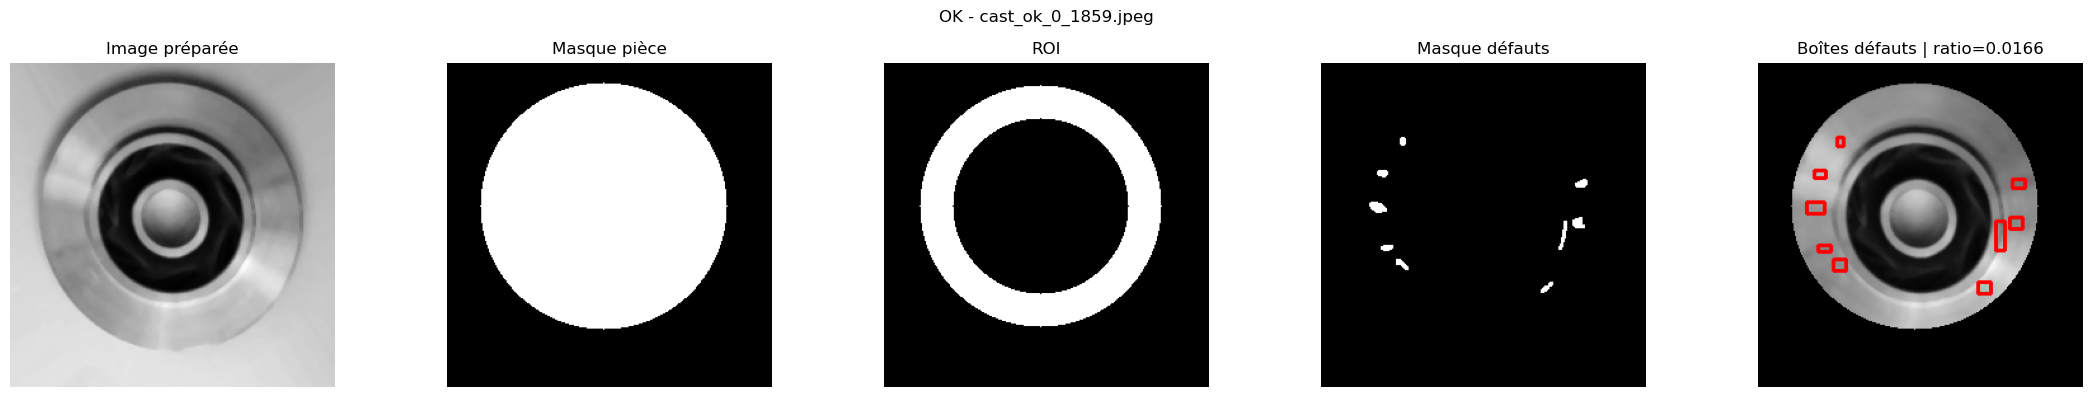

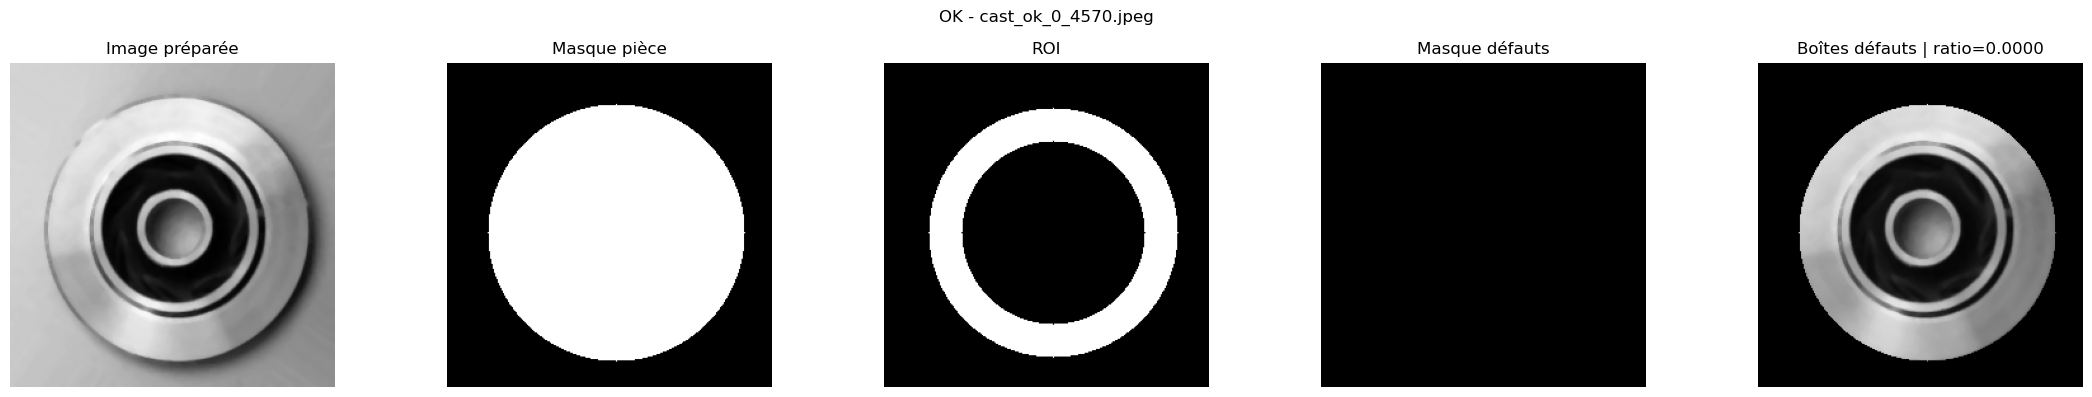

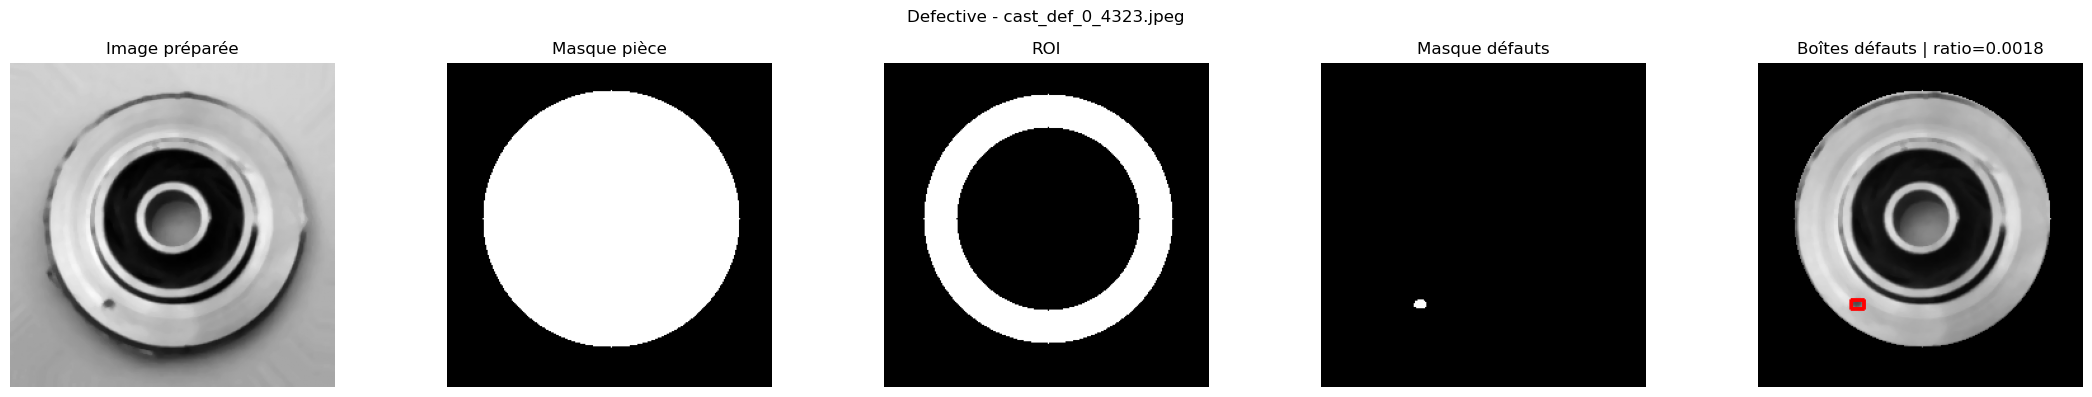

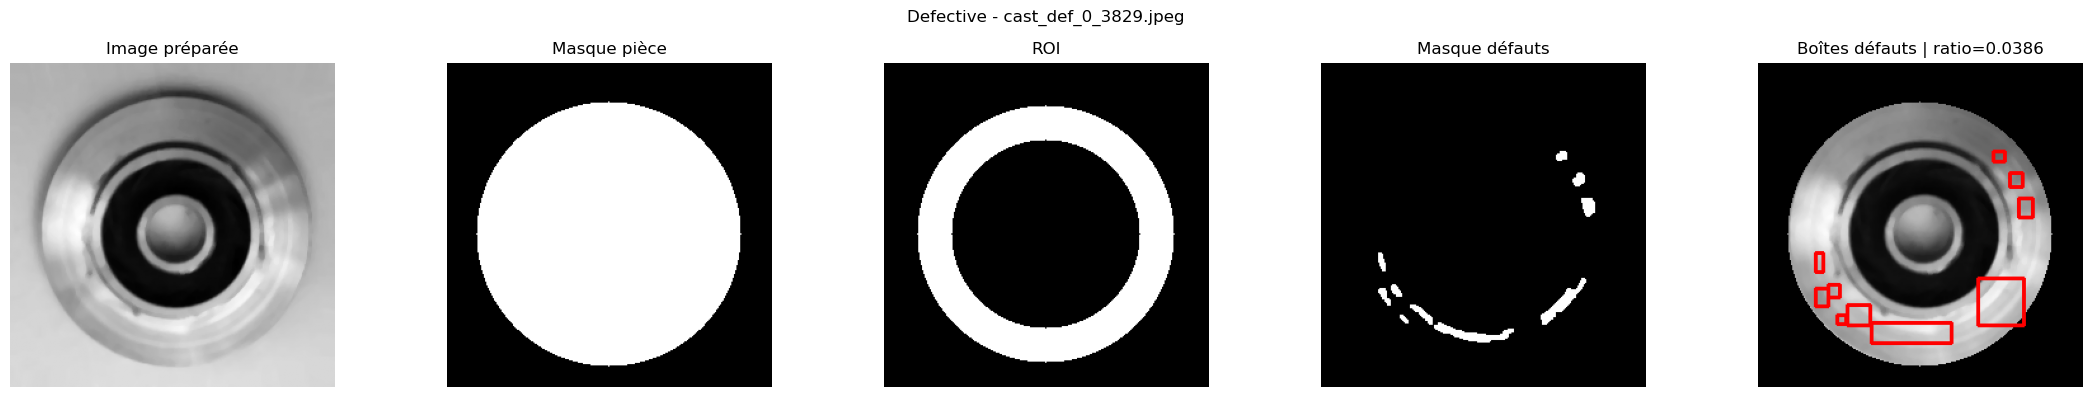

In [190]:
# ==========================================
# 22. Tester sur plusieurs images
# ==========================================

show_segmentation_examples(train_ok_images, "OK", n=2, min_area=20)
show_segmentation_examples(train_def_images, "Defective", n=2, min_area=20)

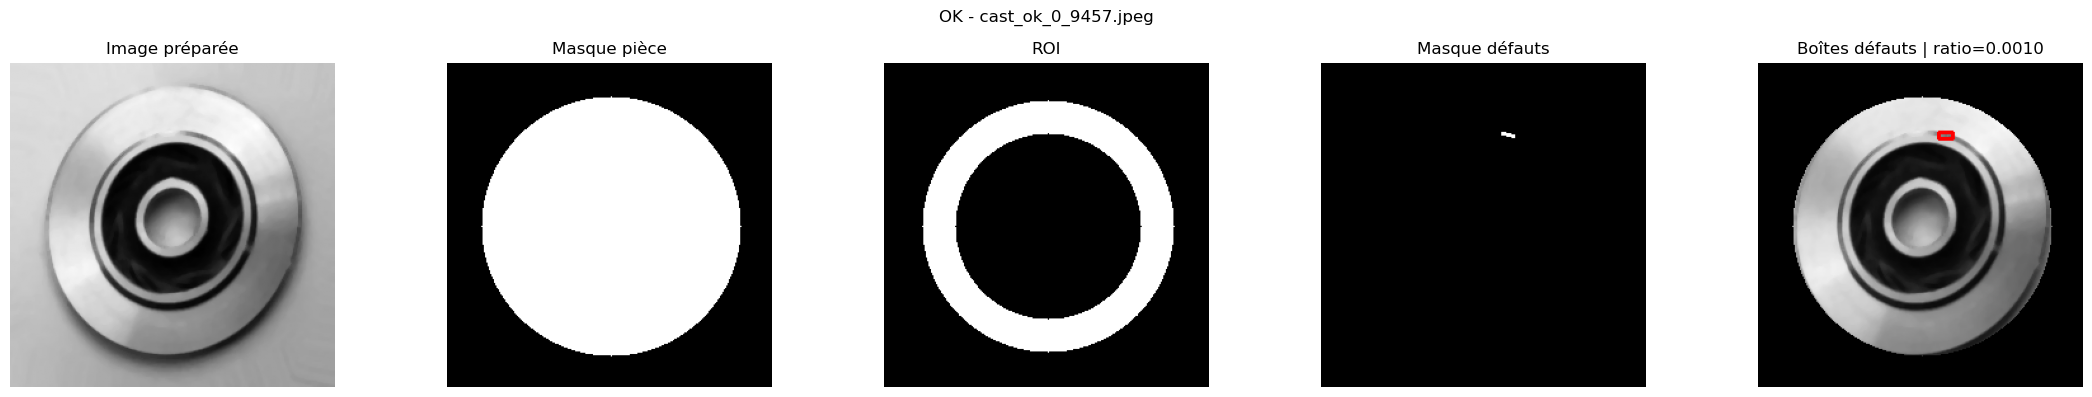

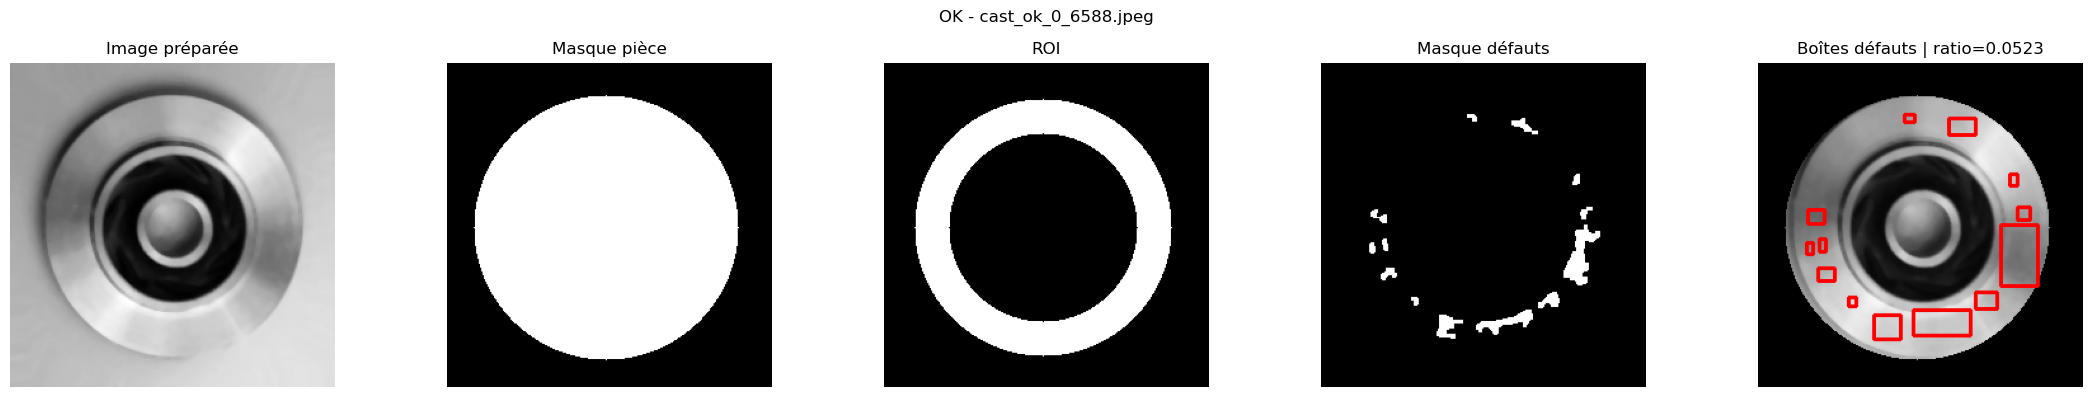

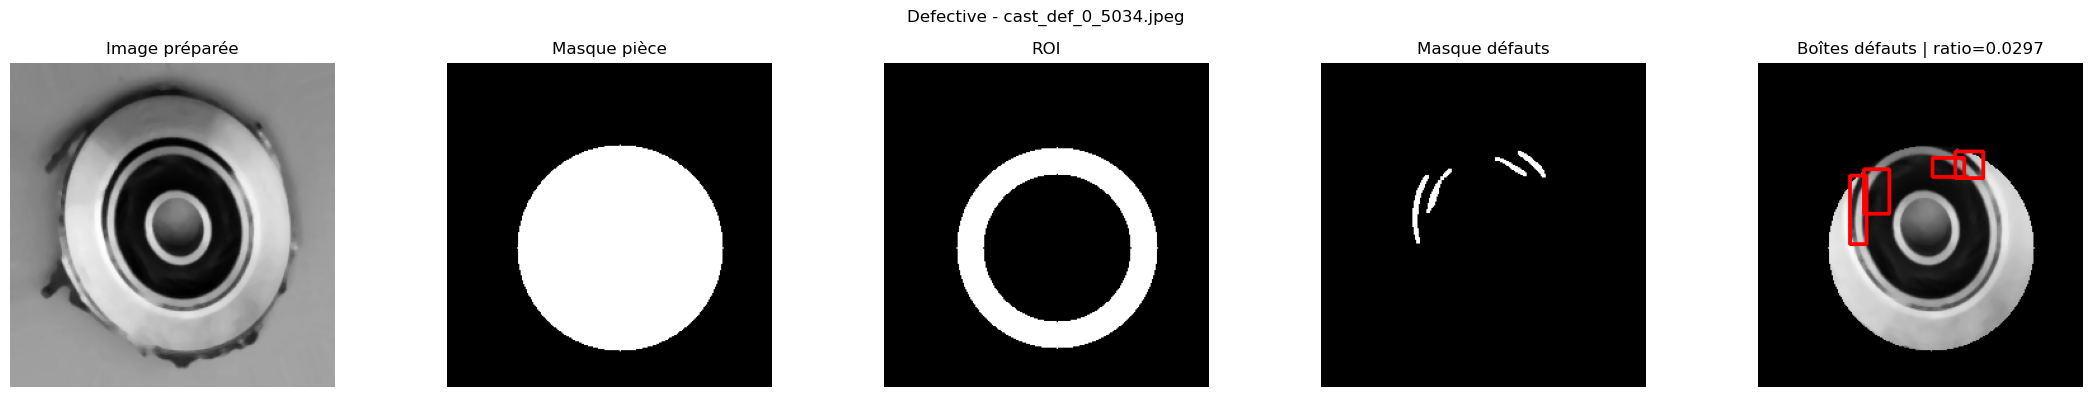

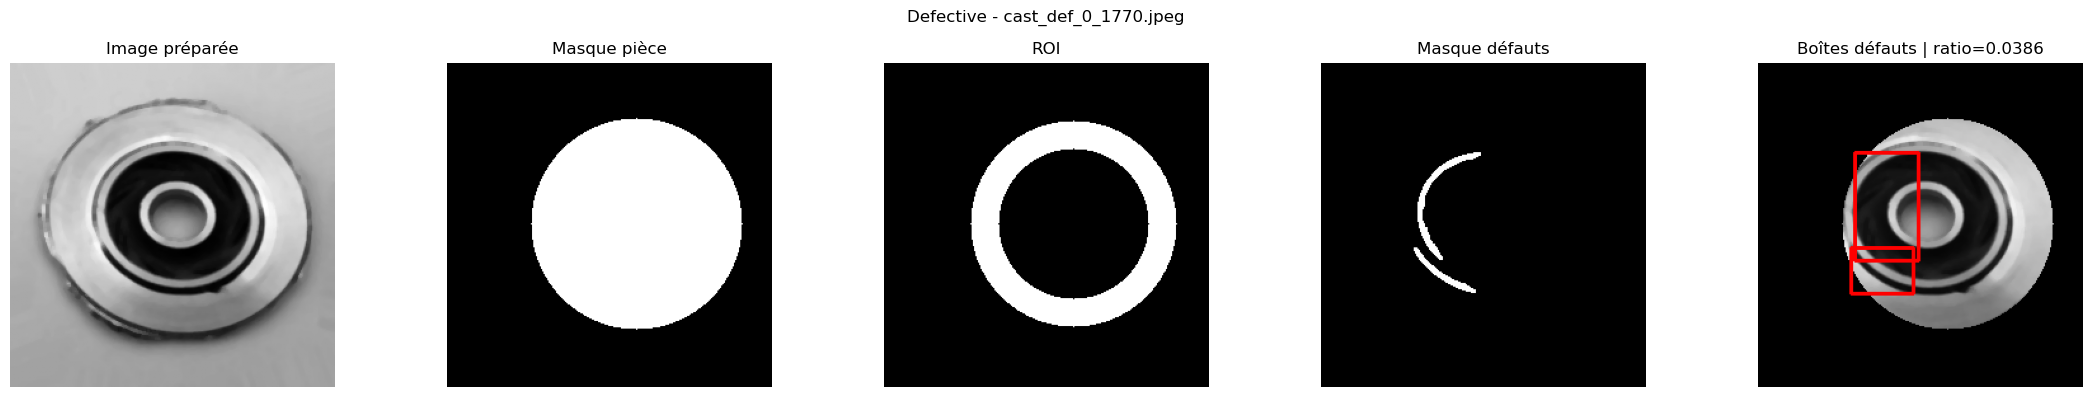

In [144]:
# ==========================================
# 23. Tester sur plusieurs images
# ==========================================

def show_segmentation_examples(image_paths, class_name, n=2, min_area=20):
    selected_paths = random.sample(image_paths, min(n, len(image_paths)))

    for path in selected_paths:
        img = load_grayscale_image(path)
        result = full_segmentation_pipeline_v2(img, min_area=min_area)

        if result is None:
            print(f"{path.name} -> segmentation impossible")
            continue

        boxes_img = draw_bounding_boxes(
            result["piece_only"],
            result["suspicious"]["filtered_contours"]
        )

        fig, axes = plt.subplots(1, 5, figsize=(22, 4))

        axes[0].imshow(result["prepared"], cmap="gray")
        axes[0].set_title("Image préparée")
        axes[0].axis("off")

        axes[1].imshow(result["main_obj"]["mask"], cmap="gray")
        axes[1].set_title("Masque pièce")
        axes[1].axis("off")

        axes[2].imshow(result["roi"], cmap="gray")
        axes[2].set_title("ROI")
        axes[2].axis("off")

        axes[3].imshow(result["suspicious"]["suspicious_mask"], cmap="gray")
        axes[3].set_title("Masque défauts")
        axes[3].axis("off")

        axes[4].imshow(boxes_img)
        axes[4].set_title(f"Boîtes défauts | ratio={result['ratio']:.4f}")
        axes[4].axis("off")

        plt.suptitle(f"{class_name} - {path.name}")
        plt.tight_layout()
        plt.show()

show_segmentation_examples(train_ok_images, "OK", n=2, min_area=20)
show_segmentation_examples(train_def_images, "Defective", n=2, min_area=20)